In [2]:
#load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("E:/Inventory_managment/data/retail_store_inventory_cleaned.csv")
print(df.head())

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Autumn  
1           

In [8]:
df['date'] = pd.to_datetime(df['Date'])


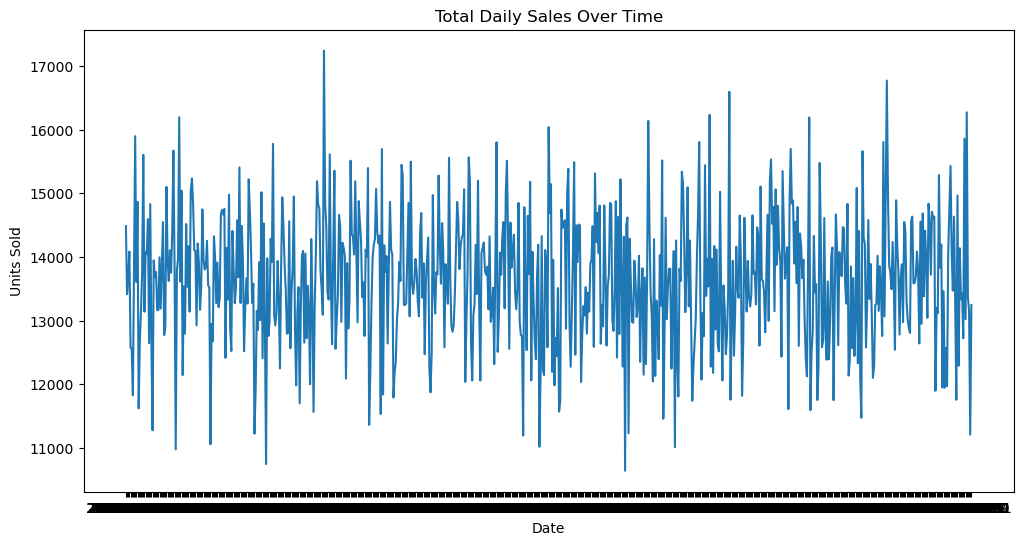

In [5]:
#Total Sales Over Time
daily_sales = df.groupby('Date')['Units Sold'].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

C:\Users\JAY\AppData\Local\Temp\ipykernel_4012\3191279612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_demand.index, y=monthly_demand.values, palette='Blues_d')


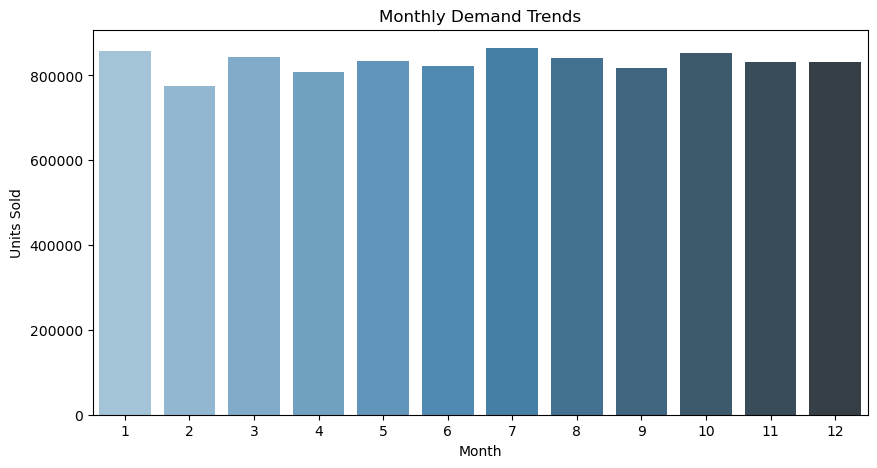

In [9]:
#Monthly Demand Trends
df['month'] = df['date'].dt.month
monthly_demand = df.groupby('month')['Units Sold'].sum()

plt.figure(figsize=(10,5))
sns.barplot(x=monthly_demand.index, y=monthly_demand.values, palette='Blues_d')
plt.title('Monthly Demand Trends')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.show()

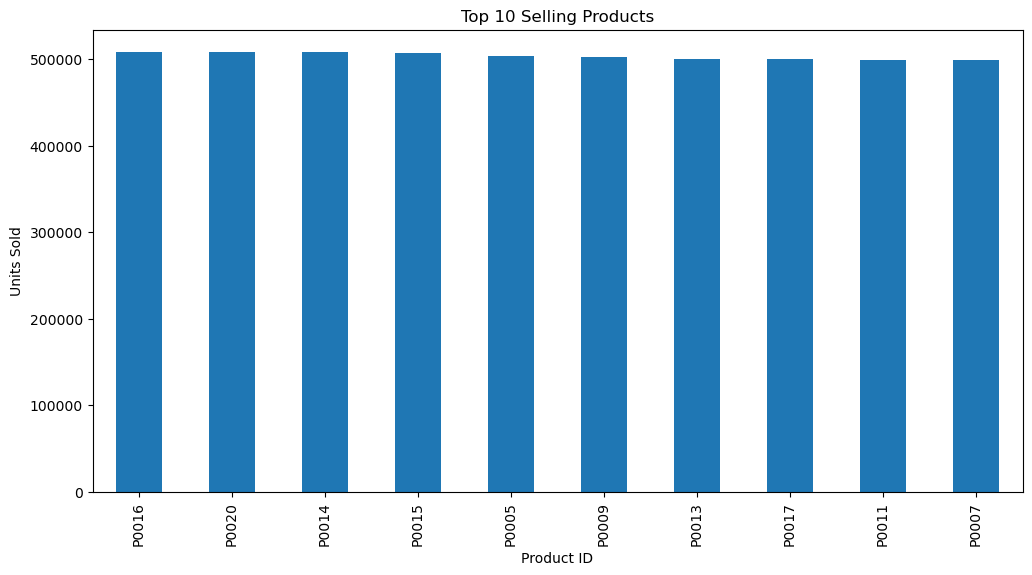

In [11]:
#Top 10 Selling Product

top_products = df.groupby('Product ID')['Units Sold'].sum()

plt.figure(figsize=(12,6))
top_products = top_products.sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Product ID')
plt.ylabel('Units Sold')
plt.show()

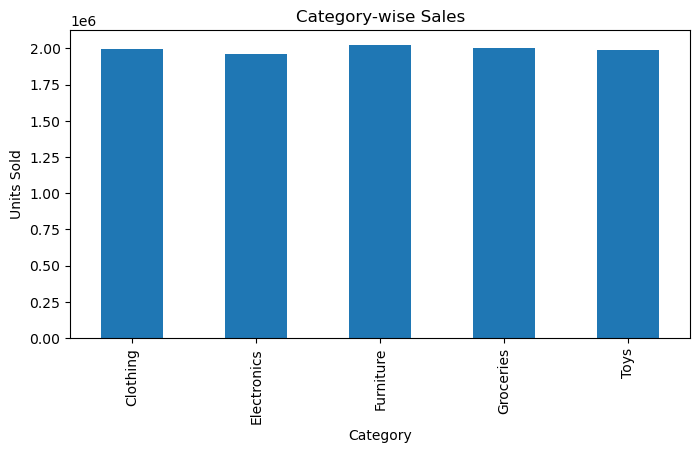

In [13]:
#Category-wise Sales
category_sales = df.groupby('Category')['Units Sold'].sum()

plt.figure(figsize=(8,4))
category_sales.plot(kind='bar')
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.show()


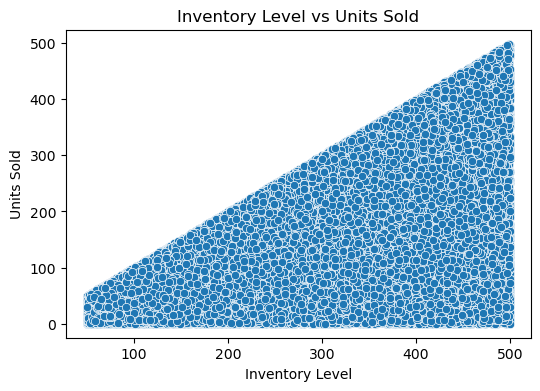

In [17]:
#Invertory Level vs Units Sold

plt.figure(figsize=(6,4))
sns.scatterplot(x='Inventory Level', y='Units Sold', data=df)
plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.show()


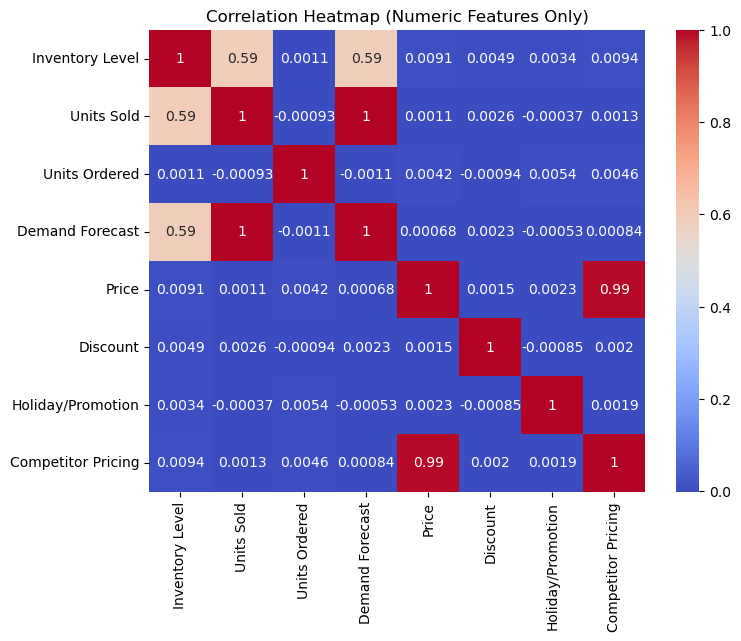

In [18]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()
